In [11]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model  import LinearRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
data = pd.read_csv("housing.csv") 
print("First 5 rows of the dataset:")  
data.head()

First 5 rows of the dataset:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [13]:
X = data[['Avg. Area House Age']] # Independent variable  
y = data['Price'] # Dependent variable  
# Check for missing values print("\nMissing values in the dataset:")  
print(data.isnull().sum()) 

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [14]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Initialize and train the linear regression model  
model = LinearRegression()  
model.fit(X_train, y_train) 
# Print model parameters 
print("Slope (β1):", model.coef_) 
print("Intercept (β0):", model.intercept_) 

Slope (β1): [159880.41760501]
Intercept (β0): 274542.9301685126


In [21]:
y_pred = model.predict(X_test) 
# Compare actual and predicted values 
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred}) 
print(comparison.head()) 

        Actual     Predicted
0  1339096.077  1.396558e+06
1  1251794.179  1.376640e+06
2  1340094.966  1.352945e+06
3  1431507.623  1.281855e+06
4  1042373.524  8.201934e+05


In [22]:
mse = mean_squared_error(y_test, y_pred)  
r2 = r2_score(y_test, y_pred) 
print("\nModel Evaluation Metrics:") 
print("Mean Squared Error (MSE):", mse)  
print("R-squared (R²):", r2)


Model Evaluation Metrics:
Mean Squared Error (MSE): 96430411520.29926
R-squared (R²): 0.21621971586826116


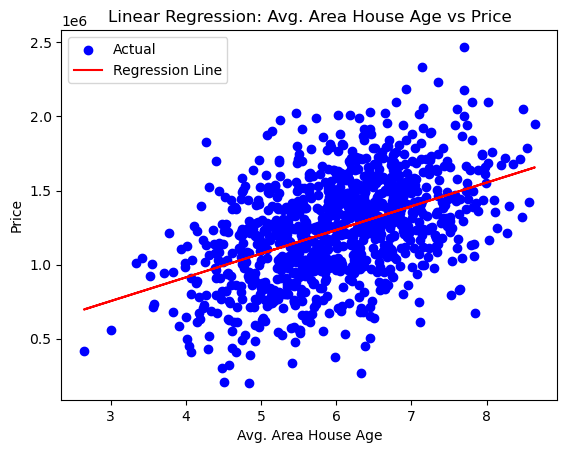

In [18]:
# Scatter plot with regression line  
plt.scatter(X_test, y_test, color='blue', label='Actual') 
plt.plot(X_test, y_pred, color='red', label='Regression Line')  
plt.xlabel("Avg. Area House Age")  
plt.ylabel("Price")  
plt.title("Linear Regression: Avg. Area House Age vs Price") 
plt.legend() 
plt.show()

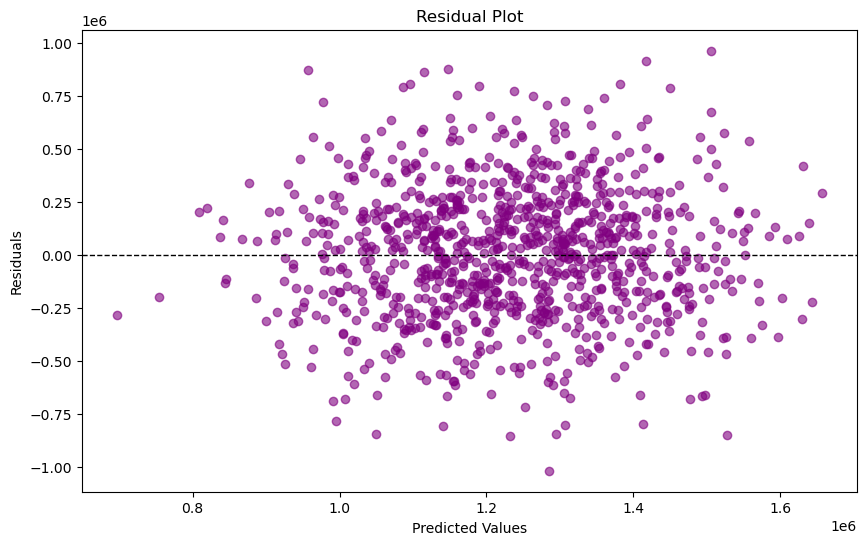

In [10]:
# Step 8: Visualize residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

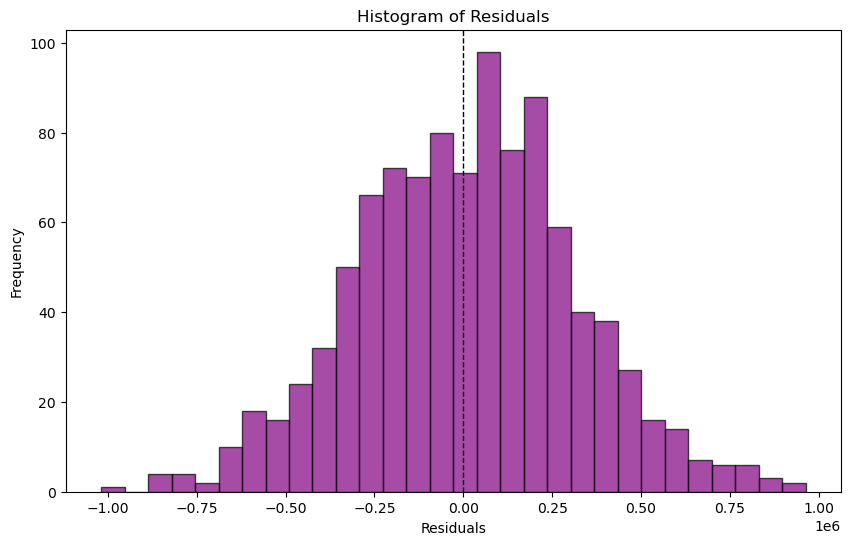

In [20]:
# Plot histogram of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Add a vertical line at 0
plt.show()

## Q1: 
     What does the slope (β1) indicate for this dataset? 

## Answer:
          The slope(β1) represents the change in the predicted house price (y) for a one-unit increase in the feature (x), assuming all other features remain constant. For example, if (β1)for Avg. Area House Age

## Q2: 
     How well does the model predict y based on the R2 value?  

## Answer:
          R2 measures the proportion of variance in the target variable (y) explained by the model. 
          An R2 close to 1 indicates a strong predictive model, while an R2 near 0 suggests the model explains little variance.
          For this dataset:
                           If R2 = 0.85 the model explains 85% of the variability in house prices.
                           A low R2 implies the need for better features, transformations, or non-linear models.

## Q3: 
     Are there any patterns in the residuals that violate linear regression assumptions?  

## Answer:
          

1. Random Scatter: 
    The residuals appear randomly distributed around the horizontal line \(y=0\). 
    This indicates that the "linearity assumption" (a linear relationship between predictors and target) is satisfied.

2. No Clear Funnel Shape: 
    The spread of residuals is fairly consistent across predicted values.
    This suggests that the "homoscedasticity assumption" (constant variance of residuals) is not violated.

3. No Systematic Patterns:
    There are no obvious clusters or systematic shapes in the residuals, supporting the "independence of errors" assumption.

4. Symmetry: 
    Residuals appear symmetrically distributed around 0, hinting that the "normality assumption" (errors are normally distributed) may also hold, though this requires further confirmation with a histogram or Q-Q plot.

Conclusion:  
           The residual plot does not show any clear patterns that would violate the linear regression assumptions. The model seems appropriate for this dataset. However, further statistical tests or diagnostics (e.g., Q-Q plots for normality) can be conducted for additional confirmation.